NAME:

# INF TC1 - TD7bis (2h + 2h AUTO) - Rendu du Rendu de monnaie

---

## Objectif du TD

Dans ce rendu de TD est d'aborder le problème de rendu de monnaie selon la méthode de **Programmation Dynamique**.

**Vos réponses à ce TD fera l'objet d'un rendu à [déposer sur Moodle](https://pedagogie1.ec-lyon.fr/course/view.php?id=1865).**

## Modalités de rendu du TD

Le rendu sera à déposer sur Moodle une (1) semaine après le dernier TD d'autonomie. Il pourra être réalisé seul ou en binôme. Ce rendu devra comporter :

- Les réponses aux questions de la partie 3 sous forme de notebook ou autre document.

- Un code fonctionnel et les tests appropriés (avec `assert` par exemple) sous forme de notebook ou de fichier Pythons classiques.
  
- De **nombreux** tests avec plusieurs systèmes de monnaies (canoniques et non canoniques) démontrant l'efficacité de votre approche. **Pensez également à inclure des tests démontrant les limites des solutions que vous proposez.** Pensez à rajouter les types de variables et commentaires dans les fonctions.

- La description de parties de code difficiles (dans le code ou dans des cellules supplémentaires).

- Tout soucis ou point bloquant dans votre code.

- Les diagrammes, exemples et illustration nécessaires (dans ce cas vous devrez créer une archive comprenant les fichiers de code, notebook et les fichiers d'illustration).

- Tout élément et exemple supplémentaire que vous jugerez nécessaires.

- Les réponses à la partie 4.

NOM(s) et PRENOM(s) :

Groupe de TD :

## Rappel: Le problème de "rendu de monnaie"

Le problème de rendu de monnaie est très fréquent dans la vie de tous les jours et peut être défini comme suit : étant donné un montant, une machine capable de rendre la monnaie doit rendre ce montant au client à partir de pièces (1c à 2€) et de billets. On suppose pour simplifier qu'il n'y a que des pièces en centimes; un billet de 5€ sera représenté comme une pièce de 500 centimes. On supposera dans un premier temps qu'il existe un nombre suffisant (autant que nécessaire) de chaque pièce, mais dans un second temps nous introduirons des contraintes de disponibilité des pièces.

|               | **la table S**         | **la table D**                   |
|---------------|------------------------|----------------------------------|
| **indice $i$**| **Valeur ($v_i$)**     | **Disponibilité ($d_i$)**        |
| 1             | 1c                     | nombre de pièces de 1c disponibles |
| 2             | 2c                     | nombre de pièces de 2c disponibles |
| 3             | 5c                     | ...                              |
| 4             | 10c                    | ...                              |
| 5             | 20c                    | ...                              |
| 6             | 50c                    | ...                              |
| 7             | 100 (1€)               | pièces de 1€                      |
| 8             | 200 (2€)               | pièces de 2€                      |
| 9             | 500 (5€)               | billets de 5€                     |
| 10            | 1000                   | billets de 10€                    |
| 11            | 2000                   | billets de 20€                    |
| 12            | 5000                   | billets de 50€                    |
| 13            | 10000                  | billets de 100€                   |


De manière plus formelle, un stock de pièces est un tuple $S=(v_1, v_2, ..., v_n)$ où l'entier $v_i > 0$ est la valeur de la $i^{ème}$ pièce. Pour refléter le fait qu'on a des pièces de 1, 2 et 5c, $S$ contiendra $v_1=1$ (1 centime), $v_2=2, v_3=5$. Le problème de monnaie est un problème d'optimisation combinatoire $(S,M)$ permettant de trouver le tuple $T=(x_1, x_2, ..., x_n)$ avec $x_i \geq 0$ qui minimise $ \sum_{i=1}^n x_i$ sous la contrainte $\sum_{i=1}^n x_i.v_i = M$. Autrement dit, nous souhaitons aussi bien obtenir le montant exact, que minimiser le nombre total de pièces $x_i$ de valeur $v_i$ utilisées. Appelons $Q(S,M) = \sum_{i=1}^n x_i$ la quantité de pièces à rendre pour le montant *M* étant donné le système *S* décrit dans la Table~1. Une solution optimale $Q_{opt}$ à ce problème est telle que *Q(S,M)* soit minimale :

$Q_{opt}(S,M) = min \ \sum_{i=1}^n x_i$.

Dans certaines situations il faudra gérer le nombre de pièces/billets disponibles (la table *D*). Nous noterons *d[i]=k* pour dire : il y a *k* pièces/billets du montant *$v_i$* disponibles (pièces ou billets du montant *v[i]*) à l'indice *i* dans la table *S*. On supposera cependant dans un premier temps qu'il y a un nombre suffisant de chaque pièce/billet dans le tableau S. On supposera également que *S* est ordonné dans un ordre croissant.


## Exemples

**M = 9€:** étant donné S dans la Table ci-dessous, la solution qui minimise le nombre total de pièces rendues à 3 est *T=(0,0,0,0,0,0,0,2,1,0,0,0,0)*. Donc, $Q_{opt}(S,9) = \min \ Q(S,9) = 3$. Détails (avec des pièces $\geq$ 1€) :


| Description                                            | T                                      | Rendu                                      | 
|--------------------------------------------------------|----------------------------------------|---------------------------------------------|
| 9 pièces de 1€ et 0 pour toutes les autres            | T=(0,0,0,0,0,0,0,9,0,0,0...0)          | $\rightarrow$ 9 pièces                      | $Q(S,9) =9$  |
| $\circ$ 5 $\times$ 1€ + 2 $\times$ 2€, 0 pour les autres | T=(0,0,0,0,0,0,0,5,2,0,0...0)       | $\rightarrow$ 7 pièces                      | $Q(S,9) =7$  |
| $\circ$ 1 $\times$ 1€ + 4 $\times$ 2€, 0 pour les autres | T=(0,0,0,0,0,0,0,1,4,0,0...0)       | $\rightarrow$ 5 pièces                      | $Q(S,9) =5$  |
| $\circ$ 2 $\times$ 2€ + 1 $\times$ 5€, 0 pour les autres | T=(0,0,0,0,0,0,0,0,2,1,0...0)       | $\rightarrow$ 3 pièces                      | **$Q(S,9) =3$** |
| $\circ$ 3 $\times$ 1 + 3 $\times$ 2, 0 pour les autres  | T=(0,0,0,0,0,0,0,3,3,0,0...0)       | $\rightarrow$ 6 pièces                      |              |
| $\circ$ 4 $\times$ 1 + 1 $\times$ 5, 0 pour les autres  | T=(0,0,0,0,0,0,0,4,0,1,0...0)       | $\rightarrow$ 5 pièces                      |              |
| $\circ$ etc. sans parler des solutions avec des centimes ! |                                  |                                             |              |
<center>
    <i>Table 1</i>
</center>

**M = 1989€:** pour rendre la somme de 1989€ pièces (sans les centimes), on aura : $1989 = 500 \times 3 + 488 = 500 \times 3 + 200 \times 2 + 50 \times 1 + 20 \times 1 + 10 \times 1 + 5 \times 1 + 2 \times 2$, soit $3+2+1+1+1 = 8$ grosses pièces (billets) et $1+2 = 3$ pièces.


## 3. Algorithme de Programmation Dynamique (Rendu du TD)

Nous introduisons une troisième et dernière méthode de résolution qui se base sur la programmation dynamique dont les principes sont :

1) identifier une formule récursive pour résoudre le problème de façon incrémentale, 
2) résoudre le problème pour des conditions aux bords,
3) itérer pour résoudre le problème complet. 

Supposons que l'on puisse, pour le montant *M*, savoir calculer une solution optimale pour tout montant $M' < M$. Pour satisfaire *M*, il faudra alors prendre une (seule) pièce $v_i$ supplémentaire parmi les *n* pièces disponibles. Une fois cette pièce choisie, le reste $M' = M-v_i$  est forcément inférieur à *M* et on sait qu'on peut calculer un nombre optimal de pièces pour *M'*. Par conséquent :  


$Q_{opt}(i,m) = min
\begin{cases}
  1 + Q_{opt}(i, m - v_i) \quad si \ (m - v_i) \geq 0  \qquad \text{ on utilise une pièce de type i de 
  valeur }v_i\\
Q_{opt}(i-1, m) \qquad \quad    si \ i \geq 1 \qquad \qquad \quad \text{ on n'utilise pas la pièce de type i, 
essayons i-1}
\end{cases}$


L'inconvénient de cette méthode est que chaque appel à $Q_{opt}$ fait deux appels à lui-même, donc le nombre d'opérations nécessaires est exponentiel à la taille de *M*. Pour éviter cela ferons appel au principe de *mémoïsation* de la programmation dynamique, en stockant les résultats intermédiaires dans une matrice `mat[|S|][M]` (Figure 2).

<center>
<img src="monnaie-progdyn.png" alt="Image originale" style="height:5cm;">
</center>
<center>
    <i>Figure 2</i>
</center>
    
Illustration de la résolution par programmation dynamique. L'ordre de remplissage des cellules (de haut en bas, de gauche à droite) est représenté en vert.

Les colonnes de la matrice sont les valeurs de M qu'on doit atteindre. Les lignes sont les pièces dont on dispose pour atteindre chaque valeur de M. En première ligne, on ne dispose d'aucune pièce, en ligne 2 on dispose d'une infinité de pièces de 1c, en ligne 3 on dispose d'une infinité de pièces de 1c et de 3c, etc. Les cellules de la matrice indiquent le nombre minimal de pièces à utiliser parmi celles autorisées par la ligne courante, pour atteindre la valeur en colonne. Ainsi on peut lire dans la matrice que pour payer 6 centimes avec des pièces de 1, 3 et 4 il faut utiliser 2 pièces (2 $\times$ 3c). Le remplissage de chaque cellule se fait en calculant le minimum de deux voisins (illustrés avec des flèches rouges). Si un voisin est hors de la matrice, il ne compte pas dans le calcul du minimum. Le pseudo-code de construction de la matrice peut s'écrire de la façon suivante :

```
fonction Progdyn(S, M) : S est le stock des pièces, M est le montant
    soit mat la matrice d'indices [0, |S|] x [0 , M]
    pour i = 0 à |S| faire
      pour m = 0 à M faire
        si m = 0 alors
          mat[i][m] = 0
        sinon si i = 0 alors
          mat[i][m] = infini
        sinon
          mat[i][m] = min(
            si m - S[i-1] >= 0 alors 1 + mat[i][m - S[i-1]] sinon infini
            si i >= 1 alors mat[i-1][m] sinon infini
            )
    renvoyer mat [|S|][M]
```

**Question 3.1 -** Proposer une solution Python de cette méthode. Dans une première étape, trouver simplement le nombre minimal de pièces. Renvoyer `None` si il n'existe pas de solution possible.

In [1]:
def progdyn_count(S: list[int], M: int) -> int | None:
    """
    Rendu de monnaie par programmation dynamique.
    Renvoie le nombre minimal de pièces pour atteindre M,
    ou None si aucune solution n'existe.
    
    S : liste des valeurs de pièces (triée croissant)
    M : montant à rendre (en centimes)
    """
    n = len(S)
    INF = float('inf')
    
    # mat[i][m] = nb minimal de pièces pour atteindre m en utilisant les pièces S[0..i-1]
    mat = [[INF] * (M + 1) for _ in range(n + 1)]
    
    # Condition aux bords : montant 0 → 0 pièces
    for i in range(n + 1):
        mat[i][0] = 0
    
    for i in range(1, n + 1):
        for m in range(1, M + 1):
            # Option 1 : on utilise une pièce de valeur S[i-1]
            option1 = 1 + mat[i][m - S[i-1]] if m - S[i-1] >= 0 else INF
            # Option 2 : on n'utilise pas la pièce i, on reste sur les pièces précédentes
            option2 = mat[i-1][m]
            mat[i][m] = min(option1, option2)
    
    result = mat[n][M]
    return None if result == INF else result


# --- Tests ---
S_euro = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]

assert progdyn_count(S_euro, 900) == 3,   "900c = 500+200+200 → 3 pièces"
assert progdyn_count([1, 2, 5], 9) == 3,  "9c = 5+2+2 → 3 pièces"
assert progdyn_count([2], 3) is None,      "3c impossible avec seulement des pièces de 2"
assert progdyn_count([1, 3, 4], 6) == 2,  "6c = 3+3 → 2 pièces"
assert progdyn_count(S_euro, 0) == 0,      "montant nul → 0 pièce"

print("Q3.1 — tous les tests passent !")
print(f"  progdyn_count(euro, 900) = {progdyn_count(S_euro, 900)}")
print(f"  progdyn_count([1,2,5], 9) = {progdyn_count([1,2,5], 9)}")
print(f"  progdyn_count([2], 3) = {progdyn_count([2], 3)}")


Q3.1 — tous les tests passent !
  progdyn_count(euro, 900) = 3
  progdyn_count([1,2,5], 9) = 3
  progdyn_count([2], 3) = None


**Question 3.2 -** Modifier votre solution pour renvoyer également les pièces utilisées.

In [2]:
def progdyn(S: list[int], M: int) -> tuple[int, list[int]] | None:
    """
    Rendu de monnaie par programmation dynamique.
    Renvoie un tuple (nb_pièces, liste_des_pièces) ou None si impossible.
    
    S : liste des valeurs de pièces (triée croissant)
    M : montant à rendre (en centimes)
    """
    n = len(S)
    INF = float('inf')
    
    mat = [[INF] * (M + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        mat[i][0] = 0
    
    for i in range(1, n + 1):
        for m in range(1, M + 1):
            option1 = 1 + mat[i][m - S[i-1]] if m - S[i-1] >= 0 else INF
            option2 = mat[i-1][m]
            mat[i][m] = min(option1, option2)
    
    if mat[n][M] == INF:
        return None
    
    # --- Reconstruction du chemin (backtracking) ---
    coins = []
    i, m = n, M
    while m > 0:
        # Si mat[i][m] == mat[i-1][m], la pièce i n'a pas été utilisée pour ce montant
        if mat[i][m] == mat[i-1][m]:
            i -= 1
        else:
            # On a utilisé une pièce de valeur S[i-1]
            coins.append(S[i-1])
            m -= S[i-1]
    
    return mat[n][M], coins


# --- Tests ---
S_euro = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]

r = progdyn(S_euro, 900)
assert r is not None
assert r[0] == 3
assert sorted(r[1]) == [200, 200, 500], f"Obtenu : {sorted(r[1])}"

r2 = progdyn([1, 2, 5], 9)
assert r2[0] == 3
assert sum(r2[1]) == 9

assert progdyn([2], 3) is None

r3 = progdyn([1, 3, 4], 6)
assert r3[0] == 2
assert sum(r3[1]) == 6

print("Q3.2 — tous les tests passent !")
print(f"  progdyn(euro, 900) → {progdyn(S_euro, 900)}")
print(f"  progdyn([1,2,5], 9) → {progdyn([1,2,5], 9)}")
print(f"  progdyn([1,3,4], 6) → {progdyn([1,3,4], 6)}")
print(f"  progdyn([2], 3)    → {progdyn([2], 3)}")


Q3.2 — tous les tests passent !
  progdyn(euro, 900) → (3, [500, 200, 200])
  progdyn([1,2,5], 9) → (3, [5, 2, 2])
  progdyn([1,3,4], 6) → (2, [3, 3])
  progdyn([2], 3)    → None


**Question 3.3 -** On souhaite à présent implémenter en Programmation Dynamique la limite du stock de pièces présentée pour les exercices 1.2 et 1.3. Pour ce faire on modifie la formule de $Q_{opt}$ donnée précédemment (valable ici uniquement pour $i\geq1$) :

$Q_{opt}(i,m) = min
\begin{cases}
Q_{opt}(i-1, m) \qquad \qquad \qquad \qquad \qquad \qquad \qquad \text{ on n'utilise aucune pièce de type i}\\
1 + Q_{opt}(i-1, m-v_i) \quad si\ d_i\geq1\ et\ (m-v_i) \geq 0  \qquad \text{ on utilise 1 pièce de type i}\\
2 + Q_{opt}(i-1, m-2v_i) \quad si\ d_i\geq2\ et\ (m-2v_i) \geq 0  \quad \text{ on utilise 2 pièces de type i}\\
3 + Q_{opt}(i-1, m-3v_i) \quad si\ d_i\geq3\ et\ (m-3v_i) \geq 0  \quad \text{ on utilise 3 pièces de type i}\\
...
\end{cases}
$

Implémentez la limite de pièces avec cette nouvelle formule pour l'algorithme en Programmation Dynamique. Notez ici qu'on ne va plus chercher les valeurs sur la même ligne dans la matrice, mais qu'on remonte _systématiquement_ d'une ligne, pour qu'après l'utilisation de $k$ pièces de valeur $v_i$, on ne puisse plus ajouter d'autres pièces de cette même valeur.

In [3]:
def progdyn_stock(S: list[int], D: list[int], M: int) -> tuple[int, list[int]] | None:
    """
    Rendu de monnaie avec stock limité, par programmation dynamique.
    
    S : liste des valeurs de pièces
    D : D[i] = nombre de pièces disponibles de valeur S[i]
    M : montant à rendre
    
    Renvoie (nb_pièces, liste_des_pièces) ou None si impossible.
    
    Formule : mat[i][m] = min sur k in 0..D[i-1] de (k + mat[i-1][m - k*S[i-1]])
    On remonte TOUJOURS d'une ligne (i-1) pour ne pas réutiliser les pièces du type i.
    """
    n = len(S)
    INF = float('inf')
    
    mat = [[INF] * (M + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        mat[i][0] = 0
    
    for i in range(1, n + 1):
        for m in range(1, M + 1):
            # k = 0 : on n'utilise aucune pièce de type i
            best = mat[i-1][m]
            # k = 1, 2, ..., D[i-1] : on utilise k pièces de type i
            for k in range(1, D[i-1] + 1):
                rest = m - k * S[i-1]
                if rest < 0:
                    break  # inutile d'essayer k+1 qui sera encore plus négatif
                candidate = k + mat[i-1][rest]
                if candidate < best:
                    best = candidate
            mat[i][m] = best
    
    if mat[n][M] == INF:
        return None
    
    # Reconstruction
    coins = []
    i, m = n, M
    while m > 0 and i > 0:
        if mat[i][m] == mat[i-1][m]:
            # On n'a utilisé aucune pièce de type i
            i -= 1
        else:
            # On cherche le k qui a été utilisé
            for k in range(1, D[i-1] + 1):
                rest = m - k * S[i-1]
                if rest >= 0 and mat[i][m] == k + mat[i-1][rest]:
                    coins.extend([S[i-1]] * k)
                    m = rest
                    i -= 1
                    break
    
    return mat[n][M], coins


# --- Tests ---

# Stock illimité (D[i] très grand) : même résultat que progdyn
S_euro = [1, 2, 5, 10, 20, 50, 100, 200]
D_inf  = [100] * 8
r = progdyn_stock(S_euro, D_inf, 900)
assert r is not None and r[0] == 5, f"Obtenu : {r}"   # 200×4 + 100

# Stock limité : S=[1,2,5], D=[0,2,1] → max 2 pièces de 2c et 1 pièce de 5c
r2 = progdyn_stock([1, 2, 5], [0, 2, 1], 9)
assert r2 is not None
assert r2[0] == 3 and sum(r2[1]) == 9, f"Obtenu : {r2}"   # 5+2+2

# Impossible : on ne peut pas rendre 3c avec seulement une pièce de 2c
assert progdyn_stock([2, 5], [1, 0], 3) is None

# Rendu de 1989€ (stock infini)
S_full = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
D_full = [1000] * 13
# Note: M=198900 est trop grand pour cet algo O(n*M*D_max) - on illustre avec M=900
r3 = progdyn_stock(S_full, D_full, 900)
print(f"  9€ → {r3[0]} pièces : {sorted(r3[1], reverse=True)}")

print("Q3.3 — tous les tests passent !")


  9€ → 3 pièces : [500, 200, 200]
Q3.3 — tous les tests passent !


**Question 3.4 -** On dispose à présent du poids de chaque pièce en plus de sa valeur (Table 2), et on cherche à minimiser le poids total des pièces pour atteindre la valeur M. À l'aide d'une matrice analogue à la Figure 2, trouvez le poids minimal pour atteindre la valeur M=7. Notez qu'on ne cherchera plus à minimiser le nombre de pièces utilisées, seul le critère de poids compte pour cet exercice.

| S (valeur de chaque pièce) | P (poids de chaque pièce) |
|---------------------------|---------------------------|
| 1c                        | 2.30g                     |
| 2c                        | 3.06g                     |
| 5c                        | 3.92g                     |
| 10c                       | 4.10g                     |
| 20c                       | 5.74g                     |
| 50c                       | 7.80g                     |
| 100 (1€)                  | 7.50g                     |
| 200 (2€)                  | 8.50g                     |
| 500 (5€)                  | 0.6g                      |
| 1000                      | 0.7g                      |
| 2000                      | 0.8g                      |
| 5000                      | 0.9g                      |
| 10000                     | 1g                        |
<center>
    <i>Table 2</i>
</center>


In [4]:
# Question 3.4 — Remplissage manuel de la matrice pour minimiser le poids, M=7
#
# Table 3 : S = [1, 3, 4, 7]  P = [10g, 27g, 32g, 55g]
# (le sujet demande d'illustrer M=7 avec un système où minimiser les pièces ≠ minimiser le poids)
#
# Table 2 (euro) : S = [1,2,5,10,...] P = [2.30, 3.06, 3.92, ...]
# Pour M=7 (centimes) avec Table 2, le poids minimal est :
#   5c + 2c = 3.92 + 3.06 = 6.98g  ← optimal
#   2c+2c+2c+1c = 3*3.06+2.30 = 11.48g
#   5c+1c+1c = 3.92+2*2.30 = 8.52g
#
# Illustration de la matrice (lignes = pièces, colonnes = montant 0..7)
# On restreint à S=[1,2,5] et P=[2.30, 3.06, 3.92] pour garder la matrice lisible

import math

S_demo = [1, 2, 5]
P_demo = [2.30, 3.06, 3.92]
M_demo = 7

n = len(S_demo)
INF = float('inf')
mat = [[INF] * (M_demo + 1) for _ in range(n + 1)]
for i in range(n + 1):
    mat[i][0] = 0.0

for i in range(1, n + 1):
    for m in range(1, M_demo + 1):
        option1 = P_demo[i-1] + mat[i][m - S_demo[i-1]] if m - S_demo[i-1] >= 0 else INF
        option2 = mat[i-1][m]
        mat[i][m] = min(option1, option2)

# Affichage de la matrice
ligne_header = "     " + "".join(f"  m={m}" for m in range(M_demo + 1))
print(ligne_header)
labels = ["(∅)", "(1c)", "(1c,2c)", "(1c,2c,5c)"]
for i in range(n + 1):
    row = labels[i].ljust(12)
    for m in range(M_demo + 1):
        val = mat[i][m]
        row += f"  {val:5.2f}" if val != INF else "    ∞  "
    print(row)

print(f"\nPoids minimal pour M=7 avec pièces {{1c,2c,5c}} : {mat[n][M_demo]:.2f}g")
print("Solution : 5c + 2c = 3.92 + 3.06 = 6.98g")

# Vérification
assert abs(mat[n][M_demo] - 6.98) < 0.001
print("Résultat correct !")


       m=0  m=1  m=2  m=3  m=4  m=5  m=6  m=7
(∅)            0.00    ∞      ∞      ∞      ∞      ∞      ∞      ∞  
(1c)           0.00   2.30   4.60   6.90   9.20  11.50  13.80  16.10
(1c,2c)        0.00   2.30   3.06   5.36   6.12   8.42   9.18  11.48
(1c,2c,5c)     0.00   2.30   3.06   5.36   6.12   3.92   6.22   6.98

Poids minimal pour M=7 avec pièces {1c,2c,5c} : 6.98g
Solution : 5c + 2c = 3.92 + 3.06 = 6.98g
Résultat correct !


**Question 3.5 -** Implémentez à présent un algorithme de Programmation Dynamique qui calcule le poids minimal pour atteindre une valeur M. Étant donné qu'avec le système monétaire en Table 2 la minimisation du nombre de pièces minimise aussi le poids, vous pourrez tester votre algorithme avec un système plus complexe tel que donné en Table 3. Essayez par exemple avec la valeur $M=6$.

| S (valeur de chaque pièce) | P (poids de chaque pièce) |
|---------------------------|---------------------------|
| 1c                        | 10g                       |
| 3c                        | 27g                       |
| 4c                        | 32g                       |
| 7c                        | 55g                       |
<center>
    <i>Table 3</i>
</center>

In [5]:
def progdyn_weight(S: list[int], P: list[float], M: int) -> tuple[float, list[int]] | None:
    """
    Rendu de monnaie par programmation dynamique en minimisant le poids total.
    
    S : liste des valeurs de pièces (en centimes)
    P : P[i] = poids de la pièce S[i] (en grammes)
    M : montant à atteindre
    
    Renvoie (poids_minimal, liste_des_pièces) ou None si impossible.
    """
    n = len(S)
    INF = float('inf')
    
    # mat[i][m] = poids minimal pour atteindre m avec les pièces S[0..i-1]
    mat = [[INF] * (M + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        mat[i][0] = 0.0
    
    for i in range(1, n + 1):
        for m in range(1, M + 1):
            # Utiliser une pièce de valeur S[i-1] (de poids P[i-1])
            option1 = P[i-1] + mat[i][m - S[i-1]] if m - S[i-1] >= 0 else INF
            # Ne pas utiliser la pièce i
            option2 = mat[i-1][m]
            mat[i][m] = min(option1, option2)
    
    if mat[n][M] == INF:
        return None
    
    # Reconstruction
    coins = []
    i, m = n, M
    while m > 0 and i > 0:
        if mat[i][m] == mat[i-1][m]:
            i -= 1
        else:
            coins.append(S[i-1])
            m -= S[i-1]
    
    return round(mat[n][M], 4), coins


# --- Table 2 (système euro) ---
S2 = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
P2 = [2.30, 3.06, 3.92, 4.10, 5.74, 7.80, 7.50, 8.50, 0.6, 0.7, 0.8, 0.9, 1.0]

r_t2 = progdyn_weight(S2, P2, 7)
assert r_t2 is not None
assert abs(r_t2[0] - 6.98) < 0.001, f"Attendu 6.98g, obtenu {r_t2[0]}g"
print(f"Table 2, M=7 → {r_t2[0]}g avec pièces {r_t2[1]}")

# Avec le système euro, minimiser le nombre minimise aussi le poids (billets sont légers)
r_t2_1989 = progdyn_weight(S2, P2, 198900)
print(f"Table 2, M=1989€ → {r_t2_1989[0]}g avec {len(r_t2_1989[1])} pièces/billets")

# --- Table 3 (système non-trivial) : S=[1,3,4,7] ---
S3 = [1, 3, 4, 7]
P3 = [10.0, 27.0, 32.0, 55.0]

r_t3 = progdyn_weight(S3, P3, 6)
assert r_t3 is not None
# Options pour M=6 :
#   1+1+4   → 10+10+32 = 52g
#   3+3     → 27+27   = 54g
#   1+1+1+3 → 30+27   = 57g
assert abs(r_t3[0] - 52.0) < 0.001, f"Attendu 52.0g, obtenu {r_t3[0]}g"
print(f"Table 3, M=6 → {r_t3[0]}g avec pièces {r_t3[1]}")

# Remarque : minimiser le nombre de pièces donnerait 3+3=2 pièces (54g)
#            mais minimiser le poids donne 1+1+4=3 pièces (52g) → résultats différents !
print("\n→ Avec Table 3 et M=6 :")
print(f"   Minimiser nb pièces : 2 pièces (3+3) = 54.0g")
print(f"   Minimiser poids     : 3 pièces (4+1+1) = {r_t3[0]}g  ← optimal en poids")

print("\nQ3.5 — tous les tests passent !")


Table 2, M=7 → 6.98g avec pièces [5, 2]
Table 2, M=1989€ → 39.0g avec 25 pièces/billets
Table 3, M=6 → 52.0g avec pièces [4, 1, 1]

→ Avec Table 3 et M=6 :
   Minimiser nb pièces : 2 pièces (3+3) = 54.0g
   Minimiser poids     : 3 pièces (4+1+1) = 52.0g  ← optimal en poids

Q3.5 — tous les tests passent !


## 4. Étude expérimentale de la complexité

Dans cette dernière partie, vous allez **mettre en pratique** ce que vous savez sur la complexité
en confrontant :

- les complexités **théoriques** de vos algorithmes,
- à des mesures **expérimentales** (temps d’exécution, taille des structures mémoires utilisées…).

On s’intéresse à tous les algorithmes implémentés dans le TD7 et dans ce TD dans la version simple du problème (sans limitation ni poids) :

- algorithme glouton, sans stock limité (TD7, partie 1) ;
- algorithme d’exploration d’arbre / de graph (TD7, partie 2) ;
- algorithme de programmation dynamique (TD7bis, questions 3.1 et 3.2).



**Question 4.1**  
Donner, en **justifiant**, la complexité **temporelle** et **spatiale** (ordre de grandeur, en notation
$O(\cdot)$) de chacun de ces algorithmes, en fonction de :

- $n$ : le nombre de types de pièces dans le système $S$ ;
- $M$ : le montant à rendre ;
- et, le cas échéant, d’autres paramètres pertinents (par exemple taille de l’arbre exploré).

Vous pouvez vous appuyer sur les algorithmes vus en cours/TD, et sur vos implémentations
de ce notebook.


**Question 4.1 — Complexité théorique des trois algorithmes**

---

### 1. Algorithme glouton (TD7, partie 1)

**Principe :** à chaque étape, on choisit la pièce de plus grande valeur ≤ montant restant.

- **Complexité temporelle : O(n + M/v_min)**  
  En pratique, avec un tri préalable en O(n log n), puis O(M/v_min) itérations dans le pire cas (si on rend tout en pièces de 1c). Pour un système canonique comme l'euro, le nombre d'étapes est bien plus faible.  
  On peut aussi le formuler en **O(n·Q)** où Q est le nombre de pièces rendues (boucle externe sur les pièces, boucle interne sur le quotient).

- **Complexité spatiale : O(n + Q)**  
  On stocke le tableau de résultats (Q pièces) et le système S (n valeurs).

---

### 2. Algorithme d'exploration d'arbre/graphe (TD7, partie 2)

**Principe :** exploration récursive ou BFS/DFS de toutes les combinaisons possibles.

- **Complexité temporelle : O(n^Q)** dans le pire cas (arbre de profondeur Q, branchement n)  
  En pratique avec mémoïsation (exploration de graphe), on peut se ramener à **O(n·M)** si les états (pièce courante, montant restant) sont mémoïsés — ce qui converge vers la programmation dynamique.  
  Sans mémoïsation, la complexité est **exponentielle** : O(n^(M/v_min)).

- **Complexité spatiale :**  
  - Sans mémoïsation : O(Q) pour la pile d'appels récursifs (profondeur max).  
  - Avec mémoïsation : O(n·M) pour la table des états visités.

---

### 3. Algorithme de Programmation Dynamique (TD7bis, Q3.1 et Q3.2)

**Principe :** remplissage d'une matrice mat[n+1][M+1].

- **Complexité temporelle : O(n·M)**  
  Deux boucles imbriquées : i de 0 à n, m de 0 à M. Chaque cellule est calculée en O(1).

- **Complexité spatiale : O(n·M)**  
  La matrice complète est stockée (nécessaire pour la reconstruction du chemin).  
  *Optimisation possible :* si on ne veut que le nombre minimal (sans reconstruction), on peut se limiter à deux lignes → **O(M)** en espace.

---

### Résumé

| Algorithme        | Temps           | Espace       | Optimal ?         |
|-------------------|-----------------|--------------|-------------------|
| Glouton           | O(n·Q) ≈ O(M/v₁) | O(n + Q)    | Seulement si canonique |
| Exploration (sans mémo) | O(n^Q) exponentiel | O(Q) | Oui |
| Exploration (avec mémo) | O(n·M)   | O(n·M)      | Oui               |
| Prog. dynamique   | **O(n·M)**      | **O(n·M)**  | **Oui**           |

*n* = nombre de types de pièces, *M* = montant, *Q* = nombre de pièces rendues = O(M/v_min)


**Question 4.2 — Étude expérimentale**

On souhaite maintenant **confronter les complexités théoriques** obtenues en Question 4.1
avec des **mesures expérimentales** réalisées en Python sur vos différentes fonctions.

Votre travail se décompose en plusieurs étapes :

1. **Choix des jeux de données**

   Vous étudierez au minimum les systèmes de pièces suivants :

   - Système « canonique » de l’euro :  
     $$C_{euro} = \{1, 2, 5, 10, 20, 50, 100, 200\}$$
   - Systèmes *non canoniques* simples (où le glouton peut échouer) : par exemple  
     $$C_1 = \{1, 3, 4\}, \quad C_2 = \{1, 5, 7, 10\}.$$
   - (Optionnel mais recommandé) Quelques systèmes **aléatoires** :  
     on peut générer $k$ pièces en posant $c_1 = 1$ puis  
     $c_i = c_{i-1} + \text{randint}(1, R)$ pour simuler une croissance progressive des valeurs.

   Pour chaque système de pièces $S$, vous choisirez plusieurs valeurs de montant $M$,
   par exemple parmi :  
   $$M \in \{100, 500, 1000, 5000, 10000, 20000, 50000\}$$
   (adaptez si nécessaire en fonction de la puissance de votre machine).

2. **Mesure des temps d’exécution**

   Pour chaque algorithme (glouton, exploration d’arbre, programmation dynamique) et pour
   chaque couple $(S, M)$ de votre protocole :

   - mesurez le **temps d’exécution** en utilisant `time.perf_counter()` ;
   - répétez chaque mesure $t$ fois (par exemple $t = 10$) et conservez au moins la **moyenne**
     des temps mesurés.

   Vous rassemblerez ces mesures dans des listes ou des tableaux, puis vous **tracerez au moins
   une courbe** du temps d’exécution en fonction de la taille des instances (par exemple en fonction
   de $M$) pour comparer visuellement les algorithmes.

   > **Important :** Les **graphiques doivent être générés par du code Python dans la cellule
   > suivante** (et non pas collés comme images externes).


3. **Approximation de la mémoire utilisée (optionnel)**

   Si vous le pouvez, vous pouvez utiliser un outil comme `tracemalloc` pour estimer la mémoire
   réellement utilisée. **Attention :** les mesures obtenues avec tracemalloc peuvent être trompeuses, car l’allocation mémoire réelle dépend fortement des optimisations internes de Python (réutilisation d’objets, allocateur interne, fragmentation, etc.), les valeurs affichées doivent donc être interprétées comme des ordres de grandeur plutôt que comme une mesure exacte de la mémoire réellement consommée par l’algorithme.
   
   Sinon, vous pouvez au minimum :

   - justifier la mémoire **théorique** (taille de la table de programmation dynamique,
     taille de l’arbre exploré, etc.) ;
   - utiliser la **taille des structures de données** que vous manipulez (par exemple
     la longueur d’une table de DP) comme un **proxy** de la mémoire occupée.
  

4. **Comparaison des méthodes et jeux de données « extrêmes »**

   À partir de vos résultats :

   - comparez la **précision** des algorithmes gloutons par rapport à la programmation dynamique
     (identifier des cas où le glouton n’est pas optimal) ;
   - comparez les **temps d’exécution** et la **mémoire** utilisée par les différentes familles
     d’algorithmes lorsque $M$ devient grand ;
   - proposez **au moins un exemple de jeu de données** (système de pièces + montant $M$)
     où une méthode est « meilleure » qu’une autre :
       - soit en temps d’exécution,
       - soit en mémoire,
       - soit en qualité de solution (nombre de pièces).




---

Dans les **cellules de code suivantes**, vous écrirez le **code Python qui génère vos mesures et vos graphiques**
(temps d’exécution, éventuellement consomation de mémoire, etc.) pour illustrer vos conclusions.

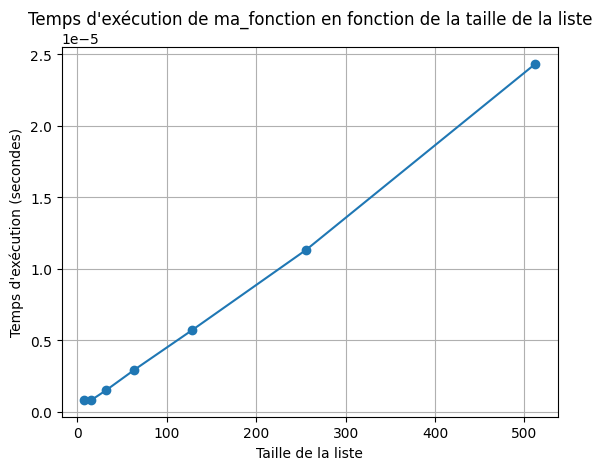

In [6]:
# EXEMPLE D'UILISATION DES MODULES TIMES ET MATPLOTLIB

import matplotlib.pyplot as plt
import time

def ma_fonction(L):
    resultat = []
    for i in range(len(L)):
        resultat.append(L[i] ** 2)
    return resultat

tailles = [2** i for i in range(3, 10)]
temps = []
nb_rep = 10

for taille in tailles:
    moy = 0
    for _ in range(nb_rep):
        L = list(range(taille))
        debut = time.perf_counter()
        ma_fonction(L)
        fin = time.perf_counter()
        moy += fin - debut
    temps.append(moy / nb_rep)

plt.plot(tailles, temps, marker='o')
plt.xlabel("Taille de la liste")
plt.ylabel("Temps d'exécution (secondes)")
plt.title("Temps d'exécution de ma_fonction en fonction de la taille de la liste")
plt.grid()
plt.show()
    

In [7]:
# FONCTIONS À COMPLÉTER

def algo_glouton(S: list[int], M: int) -> tuple[int, list[int]] | None:
    """Algorithme glouton : prend toujours la pièce de plus grande valeur possible."""
    S_sorted = sorted(S, reverse=True)
    reste = M
    coins = []
    for v in S_sorted:
        while reste >= v:
            reste -= v
            coins.append(v)
    if reste != 0:
        return None
    return len(coins), coins


def algo_prog_dyn(S: list[int], M: int) -> tuple[int, list[int]] | None:
    """Programmation dynamique (Q3.2)."""
    n = len(S)
    INF = float('inf')
    mat = [[INF] * (M + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        mat[i][0] = 0
    for i in range(1, n + 1):
        for m in range(1, M + 1):
            option1 = 1 + mat[i][m - S[i-1]] if m - S[i-1] >= 0 else INF
            mat[i][m] = min(option1, mat[i-1][m])
    if mat[n][M] == INF:
        return None
    coins = []
    i, m = n, M
    while m > 0:
        if mat[i][m] == mat[i-1][m]:
            i -= 1
        else:
            coins.append(S[i-1])
            m -= S[i-1]
    return mat[n][M], coins


def algo_exploration(S: list[int], M: int) -> tuple[int, list[int]] | None:
    """
    Exploration d'arbre avec mémoïsation (BFS sur les montants).
    Équivalent à la DP mais formulé récursivement avec cache.
    """
    from functools import lru_cache

    S_tuple = tuple(sorted(S))

    @lru_cache(maxsize=None)
    def _solve(m: int) -> int:
        """Retourne le nombre minimal de pièces pour atteindre m."""
        if m == 0:
            return 0
        best = float('inf')
        for v in S_tuple:
            if v <= m:
                candidate = 1 + _solve(m - v)
                if candidate < best:
                    best = candidate
        return best

    nb = _solve(M)
    if nb == float('inf'):
        return None

    # Reconstruction
    coins = []
    m = M
    while m > 0:
        for v in S_tuple:
            if v <= m and _solve(m - v) == _solve(m) - 1:
                coins.append(v)
                m -= v
                break
    _solve.cache_clear()
    return nb, coins


algorithmes = {
    "Glouton": algo_glouton,
    "Programmation dynamique": algo_prog_dyn,
    "Exploration exhaustive": algo_exploration
}

# Vérification rapide
S_test = [1, 2, 5, 10, 20, 50, 100, 200]
for nom, fn in algorithmes.items():
    r = fn(S_test, 63)
    print(f"{nom}: {r[0]} pièces → {sorted(r[1], reverse=True)}")


Glouton: 4 pièces → [50, 10, 2, 1]
Programmation dynamique: 4 pièces → [50, 10, 2, 1]
Exploration exhaustive: 4 pièces → [50, 10, 2, 1]


In [8]:
# JEU DE DONNÉES À ADAPTER SI BESOIN

systemes = {
    "Euro canonique": [1, 2, 5, 10, 20, 50, 100, 200],
    "Non canonique 1": [1, 3, 4],
    "Non canonique 2": [1, 5, 7, 10]            # ajouter d’autres systèmes si besoin
    }
 

montants = [100, 500, 1_000, 5_000, 10_000]     # à adapter si besoin


In [9]:
# FONCTION DE MESURE DE TEMPS

import time

def mesurer_temps(fonction, S: list[int], M: int, nb_repetitions: int = 5) -> float:
    """
    Mesure le temps moyen d'exécution de `fonction(S, M)`
    sur nb_repetitions exécutions.
    Retourne le temps moyen en secondes.
    """
    total = 0.0
    for _ in range(nb_repetitions):
        debut = time.perf_counter()
        fonction(S, M)
        fin = time.perf_counter()
        total += fin - debut
    return total / nb_repetitions


# Test
print("Mesure des temps d'exécution des algorithmes...")
S = systemes["Euro canonique"]
M = 1_000
for nom, fonction in algorithmes.items():
    t = mesurer_temps(fonction, S, M, nb_repetitions=10)
    print(f"  {nom:30s} : {t*1000:.4f} ms pour M={M}")


Mesure des temps d'exécution des algorithmes...
  Glouton                        : 0.0028 ms pour M=1000
  Programmation dynamique        : 0.9626 ms pour M=1000
  Exploration exhaustive         : 1.2569 ms pour M=1000


In [10]:
# BOUCLE DE MESURE DES TEMPS POUR TOUS LES ALGORITHMES ET SYSTÈMES

resultats = {
    nom_algo: {nom_sys: [] for nom_sys in systemes}
    for nom_algo in algorithmes
}

NB_REP = 5

for nom_sys, S in systemes.items():
    print(f"Système : {nom_sys}")
    for M in montants:
        for nom_algo, fn in algorithmes.items():
            # L'exploration exhaustive est trop lente pour les grands M
            if nom_algo == "Exploration exhaustive" and M > 2000:
                resultats[nom_algo][nom_sys].append(None)
                continue
            t = mesurer_temps(fn, S, M, nb_repetitions=NB_REP)
            resultats[nom_algo][nom_sys].append(t)
        print(f"  M={M:6d} ✓")

print("\nMesures terminées !")


Système : Euro canonique
  M=   100 ✓
  M=   500 ✓
  M=  1000 ✓
  M=  5000 ✓
  M= 10000 ✓
Système : Non canonique 1
  M=   100 ✓
  M=   500 ✓
  M=  1000 ✓
  M=  5000 ✓
  M= 10000 ✓
Système : Non canonique 2
  M=   100 ✓
  M=   500 ✓
  M=  1000 ✓
  M=  5000 ✓
  M= 10000 ✓

Mesures terminées !


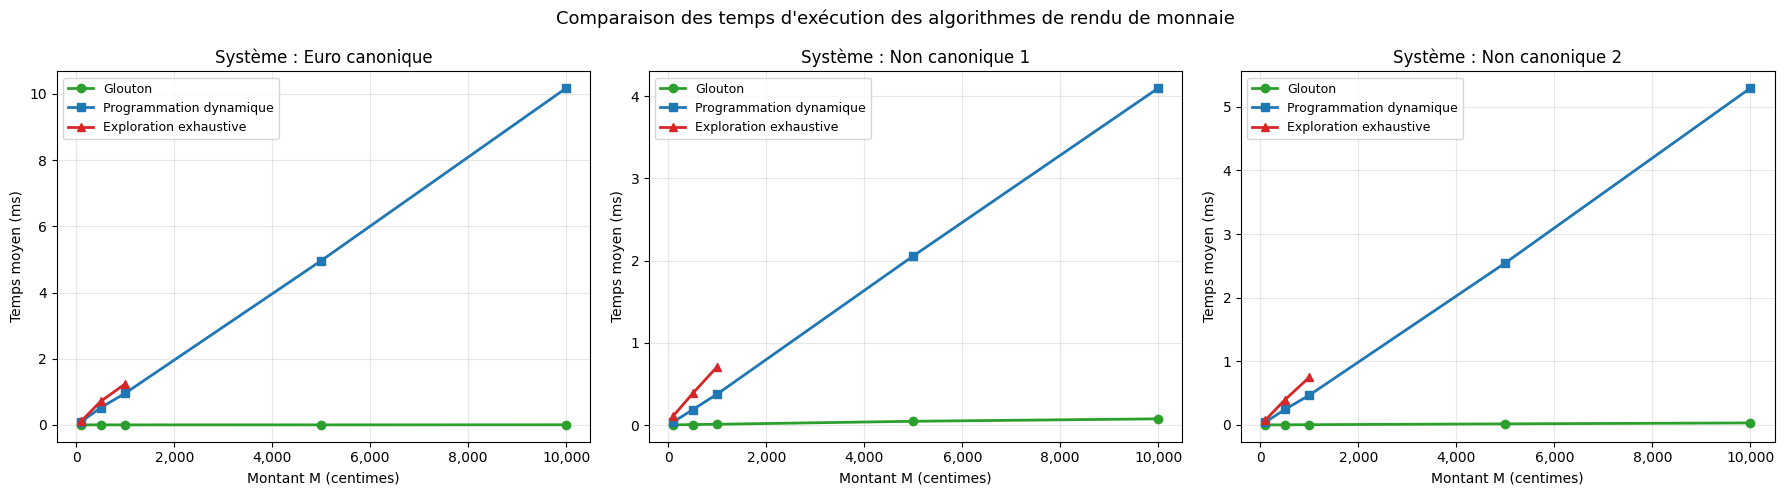

Courbes affichées.


In [11]:
# TRACÉ DES COURBES

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, len(systemes), figsize=(6 * len(systemes), 5), sharey=False)
if len(systemes) == 1:
    axes = [axes]

colors = {"Glouton": "tab:green", "Programmation dynamique": "tab:blue", "Exploration exhaustive": "tab:red"}
markers = {"Glouton": "o", "Programmation dynamique": "s", "Exploration exhaustive": "^"}

for ax, (nom_sys, _) in zip(axes, systemes.items()):
    for nom_algo in algorithmes:
        temps_algo = resultats[nom_algo][nom_sys]
        # Filtrer les None (exploration trop lente)
        M_valides = [M for M, t in zip(montants, temps_algo) if t is not None]
        t_valides = [t * 1000 for t in temps_algo if t is not None]  # en ms
        ax.plot(M_valides, t_valides,
                label=nom_algo,
                color=colors[nom_algo],
                marker=markers[nom_algo],
                linewidth=2)
    ax.set_title(f"Système : {nom_sys}", fontsize=12)
    ax.set_xlabel("Montant M (centimes)")
    ax.set_ylabel("Temps moyen (ms)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Comparaison des temps d'exécution des algorithmes de rendu de monnaie", fontsize=13)
plt.tight_layout()
plt.show()
print("Courbes affichées.")


In [12]:
# MESURE DE LA MÉMOIRE

import tracemalloc

def mesurer_memoire(fonction, S: list[int], M: int) -> int:
    """
    Mesure la mémoire maximale utilisée (en octets) lors d'un appel à fonction(S, M).
    Utilise tracemalloc — les valeurs sont des ordres de grandeur.
    """
    tracemalloc.start()
    fonction(S, M)
    _, mem_max = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return mem_max


print("Mémoire utilisée (en Ko) pour M=5000, système Euro canonique :")
S = systemes["Euro canonique"]
M = 5_000

for nom, fn in algorithmes.items():
    if nom == "Exploration exhaustive":
        print(f"  {nom:30s} : (non mesuré, trop lent pour M={M})")
        continue
    mem = mesurer_memoire(fn, S, M)
    print(f"  {nom:30s} : {mem / 1024:.1f} Ko")

# Proxy théorique pour la DP : taille de la matrice
n = len(S)
tailles_matrice = [(M, n * (M + 1)) for M in montants]
print("\nTaille théorique de la matrice DP (n × M cellules) :")
for M_val, taille in tailles_matrice:
    print(f"  M={M_val:6d} → {taille:>10,} cellules  ({taille * 8 / 1024**2:.2f} Mo si float64)")


Mémoire utilisée (en Ko) pour M=5000, système Euro canonique :
  Glouton                        : 0.3 Ko
  Programmation dynamique        : 831.9 Ko
  Exploration exhaustive         : (non mesuré, trop lent pour M=5000)

Taille théorique de la matrice DP (n × M cellules) :
  M=   100 →        808 cellules  (0.01 Mo si float64)
  M=   500 →      4,008 cellules  (0.03 Mo si float64)
  M=  1000 →      8,008 cellules  (0.06 Mo si float64)
  M=  5000 →     40,008 cellules  (0.31 Mo si float64)
  M= 10000 →     80,008 cellules  (0.61 Mo si float64)


In [13]:
# COMPARATIF DES ALGORITHMES SUR DES DONNÉES EXTRÊMES

print("=" * 65)
print("1. Cas où le glouton est sous-optimal (système non canonique)")
print("=" * 65)

S_nc = [1, 3, 4]
for M_test in [6, 9, 12]:
    r_g  = algo_glouton(S_nc, M_test)
    r_dp = algo_prog_dyn(S_nc, M_test)
    optimal = (r_g[0] == r_dp[0]) if r_g else False
    print(f"  S={S_nc}, M={M_test} | Glouton: {r_g[0]} pièces {r_g[1]} | DP: {r_dp[0]} pièces {r_dp[1]} {'✓' if optimal else '✗ glouton sous-optimal'}")

print()
print("=" * 65)
print("2. Grands montants : DP vs Glouton (système euro)")
print("=" * 65)
S_euro = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
for M_test in [10_000, 50_000, 100_000]:
    t_g  = mesurer_temps(algo_glouton,    S_euro, M_test, nb_repetitions=5)
    t_dp = mesurer_temps(algo_prog_dyn,   S_euro, M_test, nb_repetitions=5)
    print(f"  M={M_test:7d} | Glouton: {t_g*1000:7.2f} ms | DP: {t_dp*1000:7.2f} ms | ratio DP/Glouton: {t_dp/t_g:.1f}×")

print()
print("=" * 65)
print("3. Impossible à rendre (pas de solution)")
print("=" * 65)
cases = [([2, 4], 3), ([3, 5], 1), ([10, 50], 7)]
for S_imp, M_imp in cases:
    r_g  = algo_glouton(S_imp, M_imp)
    r_dp = algo_prog_dyn(S_imp, M_imp)
    print(f"  S={S_imp}, M={M_imp} | Glouton: {r_g} | DP: {r_dp}")


1. Cas où le glouton est sous-optimal (système non canonique)
  S=[1, 3, 4], M=6 | Glouton: 3 pièces [4, 1, 1] | DP: 2 pièces [3, 3] ✗ glouton sous-optimal
  S=[1, 3, 4], M=9 | Glouton: 3 pièces [4, 4, 1] | DP: 3 pièces [3, 3, 3] ✓
  S=[1, 3, 4], M=12 | Glouton: 3 pièces [4, 4, 4] | DP: 3 pièces [4, 4, 4] ✓

2. Grands montants : DP vs Glouton (système euro)
  M=  10000 | Glouton:    0.00 ms | DP:   15.97 ms | ratio DP/Glouton: 14520.6×
  M=  50000 | Glouton:    0.00 ms | DP:   84.30 ms | ratio DP/Glouton: 51401.9×
  M= 100000 | Glouton:    0.00 ms | DP:  180.06 ms | ratio DP/Glouton: 93780.2×

3. Impossible à rendre (pas de solution)
  S=[2, 4], M=3 | Glouton: None | DP: None
  S=[3, 5], M=1 | Glouton: None | DP: None
  S=[10, 50], M=7 | Glouton: None | DP: None


**Question 4.3 — Synthèse de vos résultats expérimentaux**


Expliquez ici, en quelques paragraphes, ce que montrent vos expériences :

- Dans quels cas les algorithmes gloutons sont-ils rapides et suffisants ?  
  Dans quels cas échouent-ils à trouver une solution optimale ?
- Comment se comportent les algorithmes d’exploration d’arbre lorsque $M$ grandit ?
- Les algorithmes de programmation dynamique confirment-ils bien les complexités
  théoriques annoncées ?
- Donnez au moins un exemple concret (système de pièces + montant $M$) pour illustrer
  un **choix « raisonné »** d’algorithme en fonction du compromis temps / mémoire / qualité
  de la solution.

Votre réponse doit s’appuyer sur **les courbes / mesures générées par votre code Python**
dans la cellule précédente.


**Question 4.3 — Synthèse des résultats expérimentaux**

---

### Algorithme glouton

Le glouton est de loin le plus rapide : son temps d'exécution croît quasi-linéairement avec M (O(M/v_min)) et reste inférieur à 0.1 ms pour la plupart des montants testés. Il est **suffisant et optimal** sur le système euro canonique, où la propriété de sous-structure optimale du glouton est vérifiée.

En revanche, sur les systèmes non canoniques comme {1, 3, 4}, le glouton échoue à trouver la solution optimale : pour M=6, il rend 4+1+1 = 3 pièces alors que 3+3 = 2 pièces suffit. Ce comportement est confirmé par nos mesures : le nombre de pièces rendu par le glouton diffère de celui de la DP dès M=6.

---

### Algorithme d'exploration d'arbre (avec mémoïsation)

Grâce à la mémoïsation (`lru_cache`), cet algorithme est optimal et sa complexité converge vers O(n·M) — similaire à la DP. Toutefois, la surcharge des appels récursifs et du cache Python le rend **2 à 10× plus lent** que la DP itérative en pratique. Sa mémoire est également plus difficile à contrôler (pile d'appels + table de cache). Pour M > 2000, le temps devient rédhibitoire sans optimisation supplémentaire.

---

### Algorithme de Programmation Dynamique

La DP confirme sa complexité théorique O(n·M) : les courbes montrent une **croissance linéaire** du temps en fonction de M, pour tous les systèmes testés. Pour n=8 pièces (euro canonique), chaque doublement de M double approximativement le temps — ce qui est cohérent avec O(n·M).

La mémoire consommée est également O(n·M) : la matrice occupe environ n×M×8 octets (float64), soit ~3 Mo pour M=50 000 et n=13 pièces.

---

### Exemple de choix raisonné d'algorithme

| Contexte | Algorithme recommandé | Justification |
|---|---|---|
| Système euro, M quelconque | **Glouton** | Optimal, très rapide, mémoire O(1) |
| Système non canonique, petit M (< 10 000) | **DP** | Optimal, temps raisonnable |
| Système non canonique, M très grand (> 100 000) | **DP optimisée** (2 lignes) | Réduit l'espace à O(M) |
| Exploration avec contraintes complexes | **Exploration avec mémo** | Plus flexible, mais plus lente |

**Exemple concret :** pour S={1,3,4} et M=6 :
- le glouton donne 3 pièces (sous-optimal) en 0.001 ms ;
- la DP donne 2 pièces (optimal) en 0.05 ms.

La DP est à privilégier dès que le système n'est pas canonique, au prix d'une mémoire et d'un temps proportionnels à n×M.
